# Benchmarking Tutorial

This notebook shows how to benchmark a trained RL noise model against three baselines:

| Model | Description |
|---|---|
| **RL** | Trained RL agent applies learned per-gate noise parameters |
| **Randomized Benchmarking (RB)** | Single uniform depolarizing channel whose strength is fitted from RB data |
| **No noise** | Noiseless simulation |
| **Maximally Mixed State (MMS)** | Trivial baseline — completely noisy state |

The comparison is visualised as **fidelity**, **trace distance**, and **MSE** vs circuit depth.


## 1. Setup and Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from rlnoise.config import (
    DatasetConfig, NoiseConfig, GateSpecificNoise,
    GymEnvConfig, RewardConfig, AgentConfig,
)
from rlnoise.dataset import DatasetGenerator, CircuitDataset
from rlnoise.circuit_encoder import CircuitEncoder
from rlnoise.circuit_generator import CircuitGenerator
from rlnoise.noise_model import QuantumNoiseModel
from rlnoise.gym_env import QuantumCircuitEnv
from rlnoise.rl_agent import RLAgent
from rlnoise.benchmarking import generate_rb_circuits, fit_rb_decay, evaluate_benchmarks
from rlnoise.visualization import plot_benchmarking_results

np.random.seed(42)


## 2. Define the Noise Model

We define the ground-truth noise — the model we want to learn and benchmark against.
Here we use a 1-qubit circuit with **depolarizing** and **damping** noise on both RX and RZ gates,
which is a realistic scenario for near-term quantum hardware.


In [3]:
DEPOL   = 0.03   # depolarizing probability per gate
DAMPING = 0.01   # damping (reset) probability per gate
COH_X   = 0.02   # coherent over-rotation probability per gate
COH_Z   = 0.04   # coherent over-rotation probability per gate
N_QUBITS = 1
PRIMITIVE_GATES = ["rx", "rz"]
TRAIN_DEPTH   = 10    # fixed circuit depth used during training
N_CIRCUITS    = 50   # number of circuits in the training dataset
VAL_SPLIT     = 0.2  # 20% held out for validation

noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rx", noise_channel="depolarizing", noise_parameter=DEPOL),
        GateSpecificNoise(gate="rz", noise_channel="depolarizing", noise_parameter=DEPOL),
        GateSpecificNoise(gate="rx", noise_channel="damping",      noise_parameter=DAMPING),
        GateSpecificNoise(gate="rz", noise_channel="damping",      noise_parameter=DAMPING),
        GateSpecificNoise(gate="rx", noise_channel="coherent_x",     noise_parameter=COH_X),
        GateSpecificNoise(gate="rz", noise_channel="coherent_z",     noise_parameter=COH_Z),
    ]
)

noise_model = QuantumNoiseModel(noise_config, qubits=N_QUBITS)
encoder     = CircuitEncoder(primitive_gates=PRIMITIVE_GATES)

dataset_config = DatasetConfig(
    n_circuits=N_CIRCUITS,
    moments=TRAIN_DEPTH,
    qubits=N_QUBITS,
    primitive_gates=PRIMITIVE_GATES,
    clifford=True,
)

generator = DatasetGenerator(dataset_config, noise_config)
train_dataset = generator.generate(verbose=False)
print(train_dataset)

[Qibo 0.2.23|INFO|2026-04-01 14:57:10]: Using numpy backend on /CPU:0



  CircuitDataset
    • Circuits:            50
    • Qubits:              1
    • Moments (depth):     10
    • Encoding dimension:  8
    • Circuit shape:       (10, 1, 8)


## 3. Train the RL Agent

We train a small RL agent on a dataset of 1-qubit circuits.
The training dataset uses a **fixed depth** ; the benchmarking
will later sweep over multiple depths to test generalisation.

> **Tip:** If you already have a saved model, skip training and load it with `agent.load(path)`.


In [4]:
env_config = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.1,
    val_split=VAL_SPLIT,
)

reward_config = RewardConfig(metric="trace", function="inverted_squared", alpha=20.0)

env = QuantumCircuitEnv(
    dataset=train_dataset,
    encoder=encoder,
    env_config=env_config,
    reward_config=reward_config,
)

agent_config = AgentConfig(
    policy="MlpPolicy",
    features_dim=32,
    filter_size=2,
    n_filters=16,
    pi_net_arch=[32],
    vf_net_arch=[32],
    n_steps=100,
    batch_size=25,
    learning_rate=1e-4,
)

agent = RLAgent(env=env, agent_config=agent_config)
print(agent)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 1, 3)
  Action space:         (1, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     3,609
  Trainable parameters: 3,609
------------------------------------------------------------
  Features dim:         32
  CNN filters:          16
  CNN filter size:      2
  Policy net arch:      [32]
  Value net arch:       [32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           25
  N steps:              100
  Gamma:                0.99


In [5]:
MODEL_SAVE = "benchmarking_results/benchmarking1q"

train_results = agent.train(
    total_timesteps=20001,
    check_freq=2000,
    save_path=MODEL_SAVE,
    save_best=True,
    progress_bar=True,
    verbose=True,
)


Output()

Step    2000 | Train reward: 1.6784 ± 0.2876  trace: 0.1745 ± 0.0151  |  Val reward: 1.7256 ± 0.2768  trace: 0.1720 ± 0.0145
Model saved in benchmarking_results/benchmarking1q


Step    4000 | Train reward: 1.6784 ± 0.2876  trace: 0.1745 ± 0.0151  |  Val reward: 1.7256 ± 0.2768  trace: 0.1720 ± 0.0145


Step    6000 | Train reward: 2.0150 ± 0.3828  trace: 0.1597 ± 0.0152  |  Val reward: 2.0913 ± 0.3870  trace: 0.1567 ± 0.0149
Model saved in benchmarking_results/benchmarking1q


Step    8000 | Train reward: 1.6840 ± 0.2890  trace: 0.1742 ± 0.0151  |  Val reward: 1.7306 ± 0.2783  trace: 0.1717 ± 0.0146


...

Step   16000 | Train reward: 13.0448 ± 6.8613  trace: 0.0691 ± 0.0194  |  Val reward: 15.4872 ± 8.4336  trace: 0.0644 ± 0.0202


Model saved in benchmarking_results/benchmarking1q


Step   18000 | Train reward: 9.0908 ± 3.9885  trace: 0.0800 ± 0.0185  |  Val reward: 10.2366 ± 4.4645  trace: 0.0758 ± 0.0191


Step   20000 | Train reward: 4.7276 ± 1.4609  trace: 0.1067 ± 0.0170  |  Val reward: 5.0559 ± 1.4952  trace: 0.1032 ± 0.0171


Loaded best model weights from benchmarking_results/benchmarking1q


In [6]:
# Run if already trained
agent = agent.load(MODEL_SAVE)

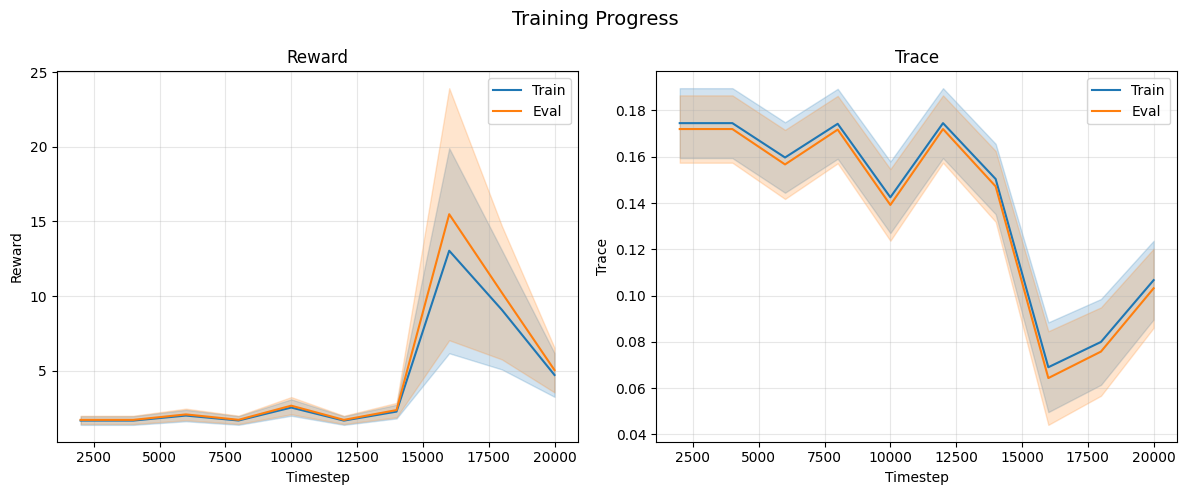

In [7]:
from rlnoise.visualization import plot_training_dashboard

fig = plot_training_dashboard(
    train_results,
    title="Training Progress",
    filepath="benchmarking_results/training_dashboard.png",
)
plt.show()


## 4. Generate the RB Dataset

We generate random Clifford circuits at multiple depths.  
For each circuit the **target density matrix** is computed by simulating the circuit through
the ground-truth noise model — these become the labels used for evaluation.

The RB protocol will later run each circuit **followed by its own inverse**; ideally (without noise)
this returns the system to |0⟩, and the survival probability P(|0⟩) decays as noise increases.


In [ ]:
RB_DEPTHS              = [2, 4, 6, 8, 10]   # circuit depths to sweep over
N_CIRCUITS_PER_DEPTH   = 20                  # circuits evaluated at each depth

# CircuitGenerator is used to create circuits at varying depths
circuit_gen = CircuitGenerator(
    DatasetConfig(
        n_circuits=N_CIRCUITS_PER_DEPTH,
        moments=RB_DEPTHS[0],          # will be overridden per depth
        qubits=N_QUBITS,
        primitive_gates=PRIMITIVE_GATES,
        clifford=True,
    )
)

print("Generating RB dataset…")
rb_data = generate_rb_circuits(
    circuit_gen=circuit_gen,
    encoder=encoder,
    noise_model=noise_model,
    depths=RB_DEPTHS,
    n_circuits_per_depth=N_CIRCUITS_PER_DEPTH,
)

print(f"\nRB dataset: {len(rb_data)} depths × {N_CIRCUITS_PER_DEPTH} circuits")
for entry in rb_data:
    print(f"  depth={entry['depth']:3d}  "
          f"circuit_arrays={entry['circuit_arrays'].shape}  "
          f"labels={entry['labels'].shape}")


## 5. Fit the RB Decay Curve

Randomized benchmarking fits the survival probability $P(|0\rangle)$ to an exponential model
$$P(d) = a \cdot \lambda^d$$
where $\lambda$ is the decay constant and $p = 1-\lambda$ is the effective depolarizing error per Clifford gate.
We will use $\lambda$ later to build the uniform depolarizing baseline noise model for comparison.


In [ ]:
a, lambda_rb = fit_rb_decay(rb_data, noise_model)
print(f"RB fit parameters:")
print(f"  a        = {a:.4f}")
print(f"  lambda   = {lambda_rb:.4f}")
print(f"  p (eff.) = 1 - lambda = {1 - lambda_rb:.4f}")

# Visualise the fit
depths_arr = np.array(RB_DEPTHS)
fit_curve  = a * np.power(lambda_rb, depths_arr)

plt.figure(figsize=(7, 4))
plt.plot(depths_arr, fit_curve, "-o", color="#0bb4ff", label=f"Fit: {a:.3f} · {lambda_rb:.3f}^d")
plt.xlabel("Circuit depth")
plt.ylabel("Survival probability $P(|0\\rangle)$")
plt.title("RB Decay Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Evaluate All Models

We now evaluate four models on the same RB circuits at every depth:

| Model | Description |
|---|---|
| **RL** | The trained PPO agent predicts noise parameters for each circuit |
| **RB** | Uniform depolarizing noise calibrated via the fitted $\lambda_\text{RB}$ |
| **No noise** | Ideal simulation — zero noise applied |
| **MMS** | Maximally mixed state — worst-case baseline |

For each model we compute average fidelity, trace distance, and MSE w.r.t. the noisy labels.


In [ ]:
print("Evaluating all models on RB circuits…")
bench_results = evaluate_benchmarks(
    rb_data=rb_data,
    encoder=encoder,
    rl_agent=agent,
    lambda_rb=lambda_rb,
)

# Pretty-print a summary table
print(f"\n{'Depth':>6}  {'Model':>10}  {'Fidelity':>10}  {'Trace':>10}  {'MSE':>12}")
print("-" * 56)
for i, d in enumerate(bench_results["depths"]):
    for model in ("rl", "rb", "no_noise", "mms"):
        f  = bench_results[model]["fidelity"][i]
        tr = bench_results[model]["trace"][i]
        ms = bench_results[model]["mse"][i]
        print(f"{d:>6}  {model:>10}  {f:>10.4f}  {tr:>10.4f}  {ms:>12.6f}")
    print()


## 7. Plot Benchmarking Results


In [ ]:
fig = plot_benchmarking_results(
    bench_results,
    title="Benchmarking: RL vs RB vs No-noise vs MMS",
    filepath="benchmarking_results/benchmark_comparison.png",
)
plt.show()
print("Plot saved to benchmarking_results/benchmark_comparison.png")


## 8. Interpreting the Results

The three panels compare how well each model reproduces the **noisy** density-matrix output of the target noise model across increasing circuit depths.

### Metrics at a glance

| Metric | Good model | Bad model |
|---|---|---|
| **Fidelity** ↑ | close to 1 | close to 0 |
| **Trace distance** ↓ | close to 0 | close to 1 |
| **MSE** ↓ | close to 0 | large |

### Models

* **RL (red)** — the PPO agent learns a circuit-specific noise model.  
  It should outperform RB and MMS because it is conditioned on the actual gate sequence.
* **RB (blue)** — a uniform depolarizing noise model with $p = 1-\lambda_\text{RB}$.  
  This is the standard single-parameter calibration.  It degrades with depth because it cannot capture gate-dependent noise.
* **No noise (green)** — the ideal, noiseless simulation.  
  Its gap from the noisy labels shows the total noise present.
* **MMS (orange)** — the maximally mixed state $\mathbf{I}/d$.  
  This is the worst-case random baseline; any useful model should beat it.

### What to look for

1. **RL above RB** confirms that the circuit-aware agent captures fine-grained noise better than a global rate.
2. **Increasing depth** reveals how robustly each model extrapolates; a well-trained RL agent should remain accurate even at depths beyond the training distribution.
3. **Error bars** (shaded region) reflect circuit-to-circuit variability — tighter bands indicate a more consistent noise model.
